In [1]:
pip install monai loguru kagglehub scikit-learn

In [2]:
import os
import torch
import torch.nn as nn
import numpy as np
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import kagglehub
from monai.transforms import (
    Compose, Resized, NormalizeIntensityd,
    RandAffined, RandAdjustContrastd, RandFlipd, RandGaussianNoised,
    EnsureTyped
)
from monai.data import DataLoader
import torchvision.models as models

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [3]:
CONFIG = {
    "batch_size": 32,
    "image_size": (512, 512),
    "num_epochs": 15,
    "learning_rate": 1e-4,
    "num_classes": 4,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "val_split": 0.15,
}

CLASS_NAMES = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]
print(f"Using device: {CONFIG['device']}")

Using device: cuda


In [4]:
# 4. Download Dataset
DATA_DIR = kagglehub.dataset_download("briscdataset/brisc2025")
train_root = Path(DATA_DIR) / "brisc2025" / "classification_task" / "train"

# Collect samples
samples = []
for class_name, label in zip(["glioma", "meningioma", "no_tumor", "pituitary"], range(4)):
    folder = train_root / class_name
    if folder.exists():
        for img_path in folder.glob("*.jpg"):
            samples.append((str(img_path), label))

print(f"Total images: {len(samples)}")

# Stratified split
train_samples, val_samples = train_test_split(
    samples,
    test_size=CONFIG["val_split"],
    stratify=[s[1] for s in samples],
    random_state=42
)

Using Colab cache for faster access to the 'brisc2025' dataset.
Total images: 5000


In [5]:
class BRISCClassDataset(torch.utils.data.Dataset):
    """
    Classification Dataset
    """
    def __init__(self, samples, image_size=(512, 512), augment=False):
        self.samples = samples
        self.image_size = image_size
        self.augment = augment

        self.aug_transform = Compose([
            Resized(keys=["image"], spatial_size=image_size),
            NormalizeIntensityd(keys=["image"], channel_wise=True),
            RandAdjustContrastd(keys=["image"], prob=0.3, gamma=(0.7, 1.3)),
            RandAffined(
                keys=["image"],
                prob=0.5,
                rotate_range=(0.26, 0.26),
                scale_range=(0.1, 0.1),
                mode="bilinear",
                padding_mode="zeros"
            ),
            RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
            RandGaussianNoised(keys=["image"], prob=0.25, std=0.08),
            EnsureTyped(keys=["image"]),
        ])

        self.val_transform = Compose([
            Resized(keys=["image"], spatial_size=image_size),
            NormalizeIntensityd(keys=["image"], channel_wise=True),
            EnsureTyped(keys=["image"]),
        ])

    def _load_image(self, path):
        img = Image.open(path).convert("RGB")
        img = img.resize(self.image_size, Image.BILINEAR)
        return np.array(img, dtype=np.float32).transpose(2, 0, 1)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = self._load_image(img_path)

        data = {"image": image}

        if self.augment:
            data = self.aug_transform(data)
        else:
            data = self.val_transform(data)

        return data["image"], label

In [6]:
train_ds = BRISCClassDataset(train_samples, image_size=CONFIG["image_size"], augment=True)
val_ds = BRISCClassDataset(val_samples,   image_size=CONFIG["image_size"], augment=False)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
                         num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                         num_workers=4, pin_memory=True)

print(f"Train dataset: {len(train_ds)} | Val dataset: {len(val_ds)}")

Train dataset: 4250 | Val dataset: 750


In [7]:
class ResNetClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_ftrs, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [8]:
model = ResNetClassifier(num_classes=CONFIG["num_classes"]).to(CONFIG["device"])

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 11,178,564


In [9]:
# ========================= TRAINING =========================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])

best_f1 = 0.0

for epoch in range(CONFIG["num_epochs"]):
    model.train()
    epoch_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['num_epochs']}"):
        images, labels = images.to(CONFIG["device"]), labels.to(CONFIG["device"])

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1} - Avg Loss: {avg_loss:.4f}")

    # Validation
    if (epoch + 1) % 5 == 0 :
        model.eval()
        all_preds, all_targets = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(CONFIG["device"])
                outputs = model(images)
                all_preds.extend(outputs.argmax(1).cpu().numpy())
                all_targets.extend(labels.numpy())

        f1 = f1_score(all_targets, all_preds, average='macro')
        acc = accuracy_score(all_targets, all_preds)

        print(f"Validation → Accuracy: {acc:.4f} | F1-macro: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), "best_brain_tumor_resnet.pth")
            print("✓ Best model saved!\n")

print(f"\nTraining finished! Best F1-macro: {best_f1:.4f}")

Epoch 1/15: 100%|██████████| 133/133 [00:11<00:00, 11.28it/s]


Epoch 1 - Avg Loss: 0.3786


Epoch 2/15: 100%|██████████| 133/133 [00:11<00:00, 11.31it/s]


Epoch 2 - Avg Loss: 0.1332


Epoch 3/15: 100%|██████████| 133/133 [00:11<00:00, 11.45it/s]


...

Epoch 14/15: 100%|██████████| 133/133 [00:11<00:00, 11.58it/s]


Epoch 14 - Avg Loss: 0.0143


Epoch 15/15: 100%|██████████| 133/133 [00:12<00:00, 10.82it/s]

Epoch 15 - Avg Loss: 0.0126


Validation → Accuracy: 0.9907 | F1-macro: 0.9910
✓ Best model saved!


Training finished! Best F1-macro: 0.9910


In [10]:
# ========================= TEST DATASET =========================
test_root = Path(DATA_DIR) / "brisc2025" / "classification_task" / "test"

test_samples = []
for class_name, label in zip(["glioma", "meningioma", "no_tumor", "pituitary"], range(4)):
    folder = test_root / class_name
    if folder.exists():
        for img_path in sorted(folder.glob("*.jpg")):
            test_samples.append((str(img_path), label))

print(f"Test set loaded: {len(test_samples)} images")

# Use the same dataset class as training (with augment=False)
test_ds = BRISCClassDataset(test_samples,
                           image_size=CONFIG["image_size"],
                           augment=False)

test_loader = DataLoader(test_ds,
                        batch_size=CONFIG["batch_size"],
                        shuffle=False,
                        num_workers=4,
                        pin_memory=True)

print(f"Test loader ready: {len(test_loader)} batches")

Test set loaded: 1000 images
Test loader ready: 32 batches



FINAL EVALUATION ON OFFICIAL TEST SET


Evaluating on Test Set: 100%|██████████| 32/32 [00:01<00:00, 25.06it/s]


Test Accuracy : 0.9870
Test F1-macro : 0.9872

              precision    recall  f1-score   support

      Glioma     0.9731    0.9961    0.9844       254
  Meningioma     0.9933    0.9641    0.9784       306
    No Tumor     0.9790    1.0000    0.9894       140
   Pituitary     0.9967    0.9967    0.9967       300

    accuracy                         0.9870      1000
   macro avg     0.9855    0.9892    0.9872      1000
weighted avg     0.9872    0.9870    0.9870      1000



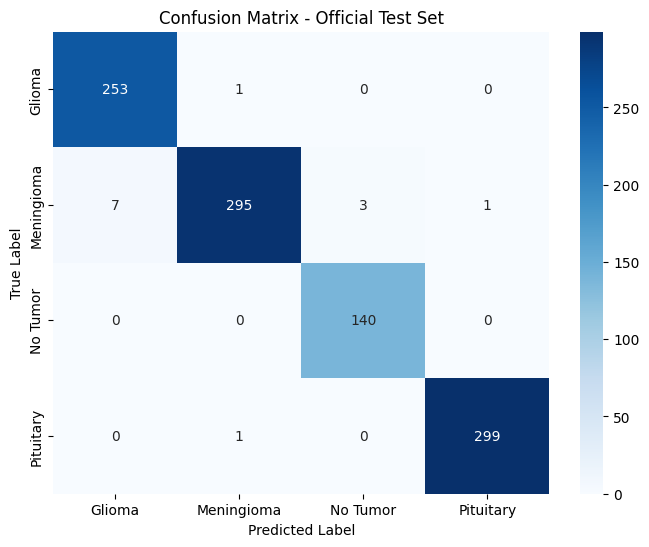

In [11]:
# ========================= FINAL EVALUATION - TEST SET =========================
print("\n" + "="*60)
print("FINAL EVALUATION ON OFFICIAL TEST SET")
print("="*60)

# Load best model
model.load_state_dict(torch.load("best_brain_tumor_resnet.pth", map_location=CONFIG["device"]))
model.eval()

all_preds, all_targets = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating on Test Set"):
        images = images.to(CONFIG["device"])
        outputs = model(images)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_targets.extend(labels.numpy())

# Metrics
acc = accuracy_score(all_targets, all_preds)
f1 = f1_score(all_targets, all_preds, average='macro')

print(f"Test Accuracy : {acc:.4f}")
print(f"Test F1-macro : {f1:.4f}\n")

print(classification_report(all_targets, all_preds, target_names=CLASS_NAMES, digits=4))

# Confusion Matrix
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - Official Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()